In [6]:
import requests
from datetime import datetime, timedelta

today = datetime.now()
week_ago = today - timedelta(days=7)

start_date = week_ago.strftime("%Y-%m-%d")
end_date = today.strftime("%Y-%m-%d")
city = input("Enter the city name: ")
#to get latitudes and longitudes of the city, we can use th
geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}"
geo_response = requests.get(geo_url, timeout=10)
geo_data = geo_response.json()

latitude= geo_data["results"][0]["latitude"]
longitude= geo_data["results"][0]["longitude"]
url=  f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_max,temperature_2m_min"

response = requests.get(url, timeout=10)
data = response.json()
print(data)

{'latitude': 21.195078, 'longitude': 81.39369, 'generationtime_ms': 0.682830810546875, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 305.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C'}, 'daily': {'time': ['2026-08-11', '2026-08-12', '2026-08-13', '2026-08-14', '2026-08-15', '2026-08-16', '2026-08-17', '2026-08-18'], 'temperature_2m_max': [30.9, 31.0, 30.3, 29.6, 29.6, 28.6, 27.8, 28.2], 'temperature_2m_min': [24.9, 25.3, 24.6, 24.9, 24.3, 23.7, 24.0, 24.2]}}


In [15]:
import pandas as pd
daily_data = data["daily"]

df = pd.DataFrame({
    'date': daily_data["time"],
    'max_temp': daily_data["temperature_2m_max"],
    'min_temp': daily_data["temperature_2m_min"]
})

df['date'] = pd.to_datetime(df['date'])
print(df)

        date  max_temp  min_temp
0 2026-08-11      30.9      24.9
1 2026-08-12      31.0      25.3
2 2026-08-13      30.3      24.6
3 2026-08-14      29.6      24.9
4 2026-08-15      29.6      24.3
5 2026-08-16      28.6      23.7
6 2026-08-17      27.8      24.0
7 2026-08-18      28.2      24.2


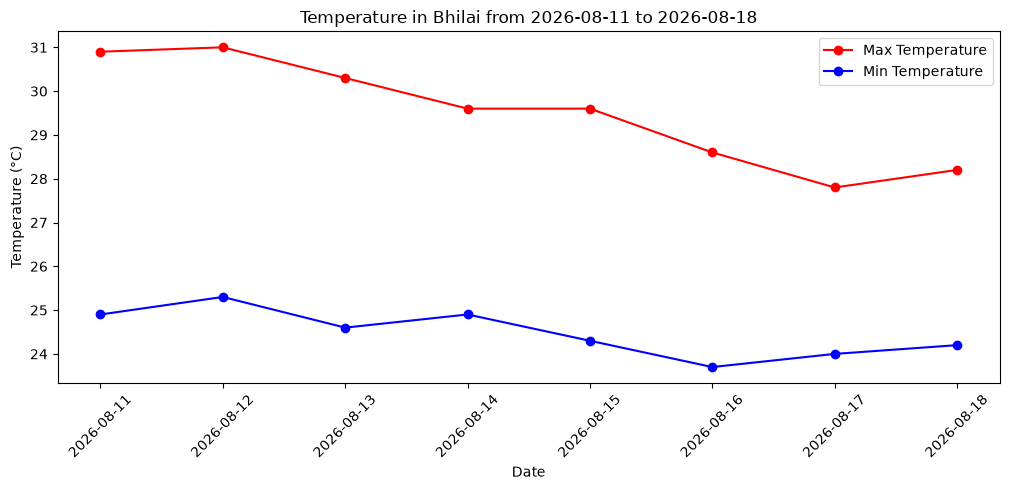

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['max_temp'], label='Max Temperature', color='red', marker='o')
plt.plot(df['date'], df['min_temp'], label='Min Temperature', color='blue', marker='o')
plt.title(f"Temperature in {city} from {start_date} to {end_date}")

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.tight_layout()
plt.ylabel('Temperature (°C)')
plt.legend()
plt.savefig('weather_chart.png')
plt.show()